## Standardization?

Feature Scaling (Standardization) is a technique used in data preprocessing to normalize the range of independent features (input variables) in a dataset. It is especially important in machine learning algorithms that rely on distances (like KNN, SVM, or gradient descent-based models like logistic regression and neural networks).

#### What is Standardization?
Standardization is one type of feature scaling where the features are rescaled so that they have:
Mean (μ) = 0
Standard deviation (σ) = 1

The formula for standardization is:  $z = \frac{x - \mu}{\sigma}$

Where:  
- x is the original value,
- μ is the mean of the feature,
- σ is the standard deviation of the feature,
- z is the standardized value.
#### Why is Standardization Important?
1. Equal Treatment of Features: Features with larger scales can dominate the model if not scaled properly.
2. Faster Convergence: For gradient-based algorithms (like logistic regression, neural networks), it helps the model converge faster.
9. Improves Model Performance: Algorithms like SVMs and KNN rely on distance metrics, and unscaled features can skew distance calculations.
4.Regularization Works Better: Techniques like Lasso and Ridge regression are sensitive to the scale of features.

#### When to Use Standardization?
When your data follows a Gaussian (normal) distribution.
When using algorithms sensitive to feature scale, such as:

1. Logistic Regression
2. SVM
3. K-Means
4. KNN
5. PCA (Principal Component Analysis)
6. Neural Networks

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("00_raw_data/bank-loan.csv")
dataset.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [3]:
dataset.isnull().sum()

age           0
ed            0
employ        0
address       0
income        0
debtinc       0
creddebt      0
othdebt       0
default     150
dtype: int64

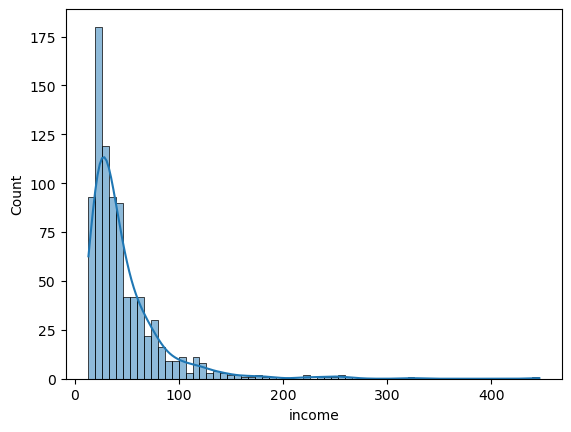

In [4]:
sns.histplot(dataset['income'], kde = True)
plt.show()

In [5]:
dataset.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000


In [6]:
from sklearn.preprocessing import StandardScaler

In [7]:
ss = StandardScaler()
ss.fit(dataset[['income']])

StandardScaler()

In [8]:
dataset['Income_new'] = pd.DataFrame(ss.transform(dataset[['income']]), columns=['Income_new'])

In [9]:
dataset.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,Income_new
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,3.357307
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,-0.406935
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0,0.216112
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0,1.903530
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0,-0.484816


In [10]:
dataset.describe()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,Income_new
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,8.500000e+02
mean,35.029412,1.710588,8.565882,8.371765,46.675294,10.171647,1.576805,3.078789,0.261429,8.359326e-17
std,8.041432,0.927784,6.777884,6.895016,38.543054,6.719441,2.125840,3.398803,0.439727,1.000589e+00
min,20.000000,1.000000,0.000000,0.000000,13.000000,0.100000,0.011696,0.045584,0.000000,-8.742203e-01
25%,29.000000,1.000000,3.000000,3.000000,24.000000,5.100000,0.382176,1.045942,0.000000,-5.886572e-01
50%,34.000000,1.000000,7.000000,7.000000,35.000000,8.700000,0.885091,2.003243,0.000000,-3.030940e-01
75%,41.000000,2.000000,13.000000,12.000000,55.750000,13.800000,1.898440,3.903001,1.000000,2.355820e-01
max,56.000000,5.000000,33.000000,34.000000,446.000000,41.300000,20.561310,35.197500,1.000000,1.036658e+01


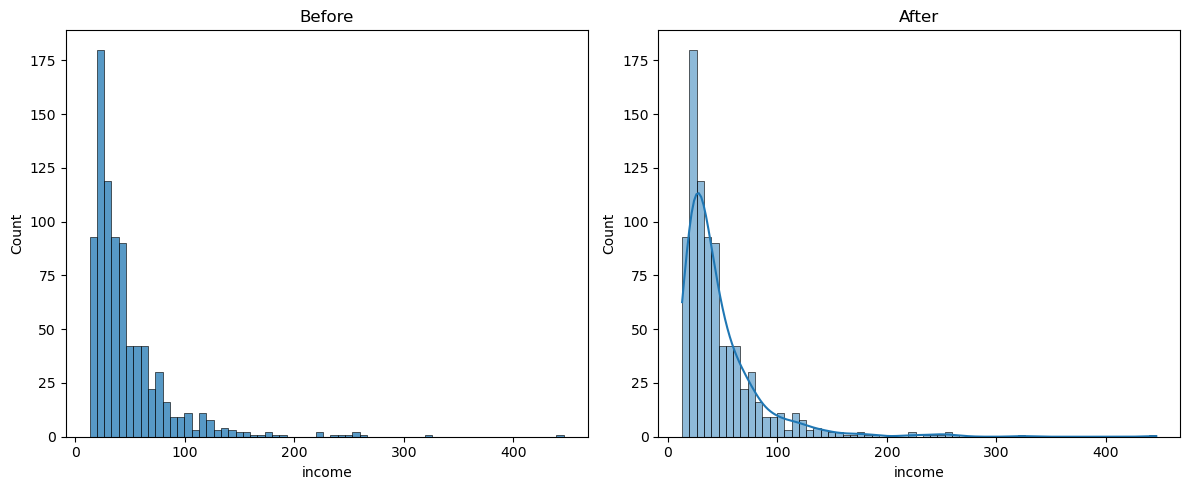

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(dataset['income'], kde=False)

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(dataset['income'], kde=True)

plt.tight_layout()
plt.show()

## Normalization

### What is Normalization?
Normalization, also known as Min-Max Scaling, is a technique that transforms features to a fixed range, usually [0, 1]. This helps models treat all features equally.
#### Formula
$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

#### Where:

- x = original value
- $ x_{\min} $ = minimum value of the feature 
- $ x_{\max} $  = maximum value of the feature
- $ x' $ = normalized value (between 0 and 1)

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
datasetMS = pd.read_csv("00_raw_data/bank-loan.csv")
datasetMS.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [14]:
ms = MinMaxScaler()
ms.fit(dataset[['debtinc']])

MinMaxScaler()

In [15]:
datasetMS["debtinc_min"] = ms.transform(datasetMS[['debtinc']])

In [16]:
datasetMS.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default,debtinc_min
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0,0.223301
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0,0.417476
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0,0.131068
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0,0.067961
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0,0.417476


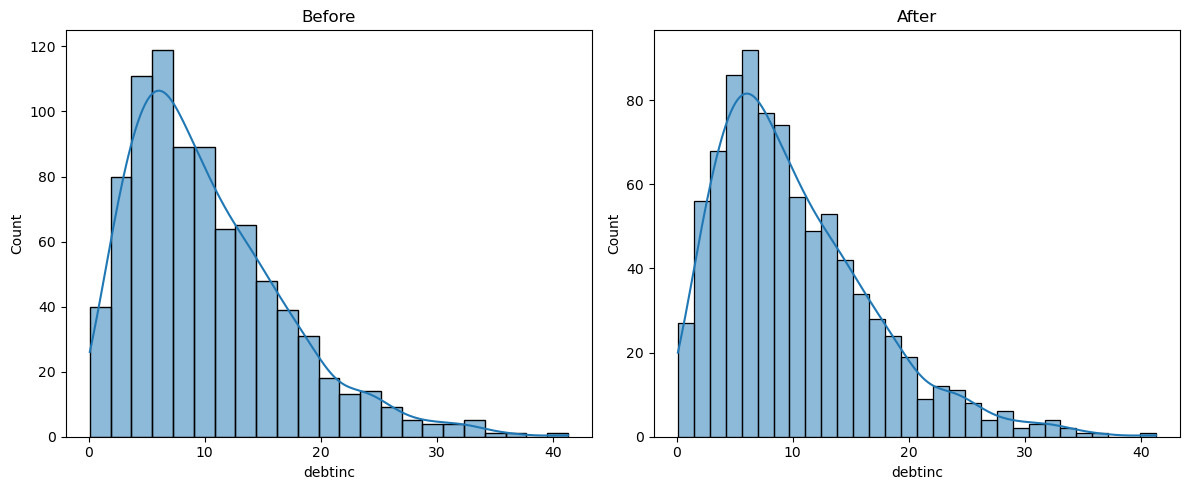

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("Before")
sns.histplot(datasetMS['debtinc'], kde=True)

plt.subplot(1,2,2)
plt.title("After")
sns.histplot(datasetMS['debtinc'], kde=True, bins=30)

plt.tight_layout()
plt.show()

### What is **MaxAbsScaler**?

**MaxAbsScaler** scales each feature by **its maximum absolute value**, transforming the data into the range **\[-1, 1]**. Unlike MinMaxScaler, it **doesn’t shift or center** the data — only scales.

### **Formula:**

$$
x' = \frac{x}{\max(|x|)}
$$

Where:

* $x$ = original value
* $x'$ = scaled value
* $\max(|x|)$ = maximum absolute value of the feature

### **When to Use MaxAbsScaler:**

* Data contains **both positive and negative values**
* You want to **preserve sparsity** (works well with sparse data)
* Models sensitive to scale but not to centering (e.g., SVMs, linear models)

###  Not suitable when:

* Data needs centering (mean = 0)
* There are extreme outliers (use **RobustScaler** instead)


In [18]:
from sklearn.preprocessing import MaxAbsScaler

In [19]:
datasetMA = pd.read_csv("00_raw_data/bank-loan.csv")
datasetMA.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [20]:
X = datasetMA.drop('default', axis=1)
y = datasetMA['default']

In [21]:
# Create scaler
scaler = MaxAbsScaler()

In [22]:
# Fit and transform the data
X_scaled = scaler.fit_transform(X)

In [23]:
# Create DataFrame with scaled values
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [24]:
df_scaled

,age,ed,employ,address,income,debtinc,creddebt,othdebt
0,0.732143,0.6,0.515152,0.352941,0.394619,0.225182,0.552464,0.142300
1,0.482143,0.2,0.303030,0.176471,0.069507,0.418886,0.066251,0.113667
2,0.714286,0.2,0.454545,0.411765,0.123318,0.133172,0.041635,0.061622
3,0.732143,0.2,0.454545,0.411765,0.269058,0.070218,0.129307,0.023333
4,0.428571,0.4,0.060606,0.000000,0.062780,0.418886,0.086932,0.086840
...,...,...,...,...,...,...,...,...
845,0.607143,0.2,0.363636,0.441176,0.071749,0.065375,0.011640,0.017748
846,0.571429,0.4,0.363636,0.323529,0.260090,0.138015,0.195839,0.073451
847,0.857143,0.2,0.393939,0.323529,0.085202,0.261501,0.035129,0.096078
848,0.625000,0.4,0.030303,0.323529,0.053812,0.188862,0.020303,0.041325


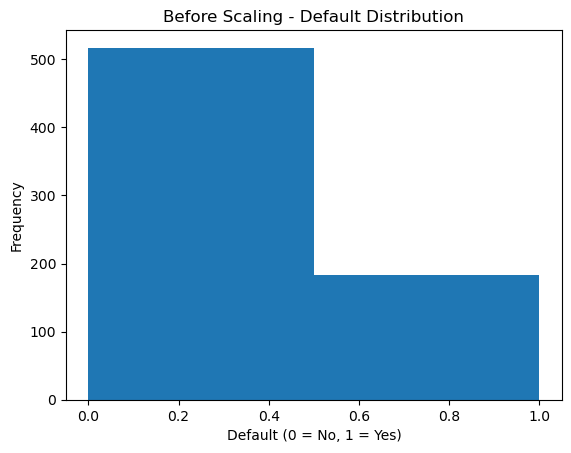

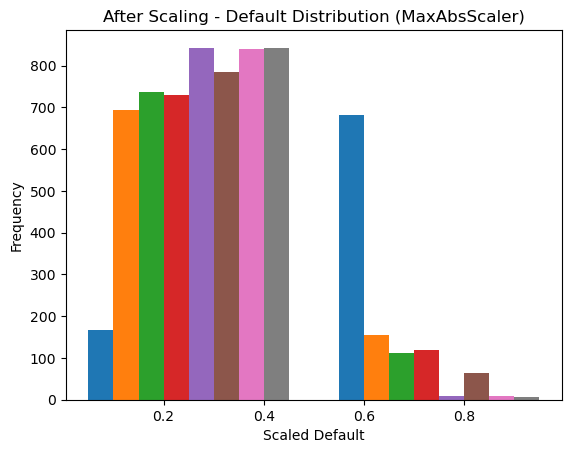

In [25]:
# BEFORE Scaling
plt.figure()
plt.hist(datasetMA['default'], bins=2)
plt.title("Before Scaling - Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Frequency")
plt.show()

# AFTER Scaling
plt.figure()
plt.hist(df_scaled, bins=2)
plt.title("After Scaling - Default Distribution (MaxAbsScaler)")
plt.xlabel("Scaled Default")
plt.ylabel("Frequency")
plt.show()

### What is **RobustScaler**?

**RobustScaler** is a scaling technique that **reduces the influence of outliers** by using the **median** and **interquartile range (IQR)** instead of mean and standard deviation.

### **Formula:**

$$
x' = \frac{x - \text{median}(x)}{\text{IQR}(x)}
$$

Where:

* $x$ = original value
* $\text{median}(x)$ = 50th percentile
* $\text{IQR}(x) = Q3 - Q1$ = 75th percentile − 25th percentile

### **When to Use RobustScaler:**

* Your data contains **outliers**
* You want a scale that is **resistant to extreme values**
* Works well with algorithms sensitive to scale (e.g., linear models, SVM, KNN)

### Comparison:

| Scaler         | Handles Outliers? | Range          | Centers Data   |
| -------------- | ----------------- | -------------- | -------------- |
| StandardScaler | No              | Varies         | Yes (mean=0)   |
| MinMaxScaler   |  No              | \[0, 1]        | No             |
| MaxAbsScaler   |  No              | \[-1, 1]       | No             |
| RobustScaler   |  Yes             | Depends on IQR | Yes (median=0) |


In [26]:
from sklearn.preprocessing import RobustScaler

In [27]:
datasetF = pd.read_csv("00_raw_data/bank-loan.csv")
datasetF.head()

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,3,17,12,176,9.3,11.359392,5.008608,1.0
1,27,1,10,6,31,17.3,1.362202,4.000798,0.0
2,40,1,15,14,55,5.5,0.856075,2.168925,0.0
3,41,1,15,14,120,2.9,2.658720,0.821280,0.0
4,24,2,2,0,28,17.3,1.787436,3.056564,1.0


In [28]:
#  Select numeric features to scale (excluding target)
features = ['age','ed','employ','address','income','debtinc','creddebt','othdebt']

In [29]:
# Create RobustScaler
scaler = RobustScaler()

In [30]:
df_scaled = datasetF.copy()

In [31]:
# Fit and transform the data
df_scaled[features] = scaler.fit_transform(dataset[features])

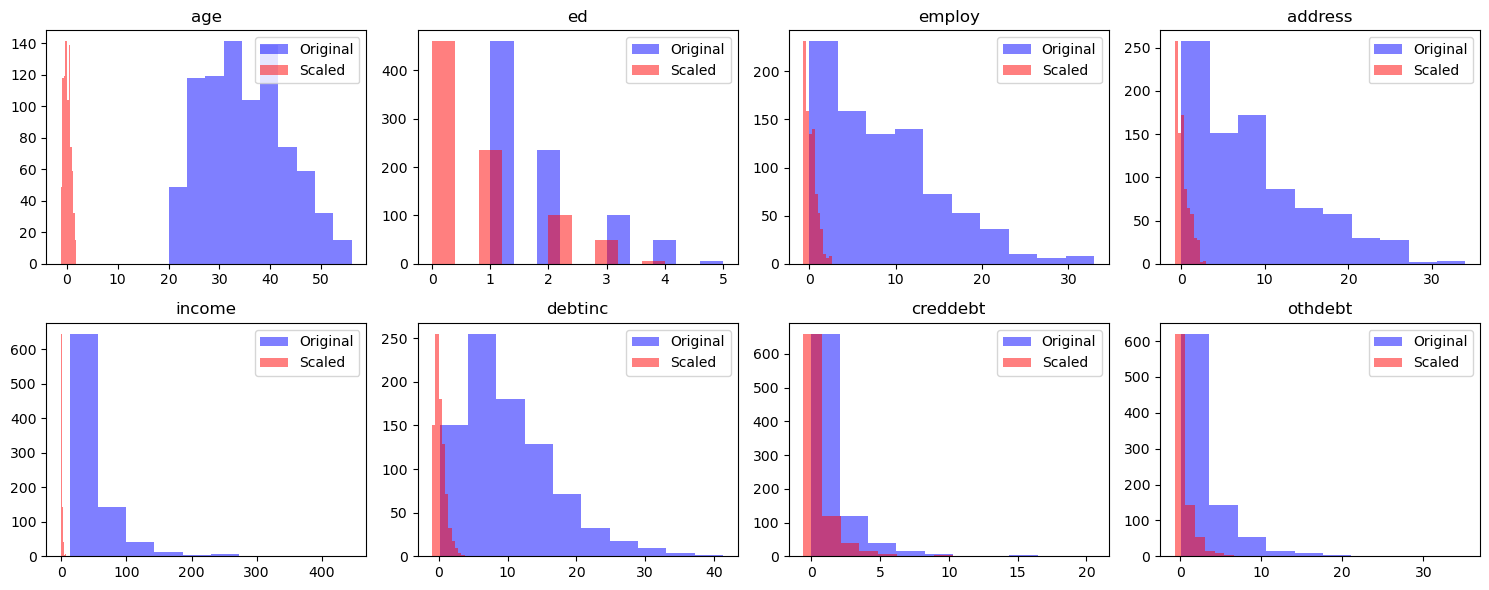

In [32]:
plt.figure(figsize=(15,6))

for i, col in enumerate(features):
    plt.subplot(2, 4, i+1)
    plt.hist(datasetF[col], bins=10, alpha=0.5, label='Original', color='blue')
    plt.hist(df_scaled[col], bins=10, alpha=0.5, label='Scaled', color='red')
    plt.title(col)
    plt.legend()

plt.tight_layout()
plt.show()